# Potential and Limitation of QELMs

In this notebook I want to reprodue the results of https://arxiv.org/abs/2210.00780.

First of all I want to generate a training dataset, a set of denisty matrices with the corresponding expectation value of chosen observable.

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#let's define the Pauli matrices
I = np.array([[1, 0],
              [0, 1]], dtype=complex)

X = np.array([[0, 1],
              [1, 0]], dtype=complex)

Y = np.array([[0, -1j],
              [1j,  0]], dtype=complex)

Z = np.array([[1,  0],
              [0, -1]], dtype=complex)

In [2]:
N_tr = 100
N_test = 1000

#density matrices
rho_training = np.zeros((N_tr, 2, 2), dtype=complex)
rho_test = np.zeros((N_test,2,2), dtype=complex)

#expectation values
expe_X_train = np.zeros(N_tr)
expe_X_test = np.zeros(N_test)

In [3]:
for i in range(N_tr):
    #sample a random Bloch vector uniformly in the Bloch ball
    r = np.random.normal(size=3)
    r = r / np.linalg.norm(r) * np.random.rand()**(1/3)
    
    #construct density matrix
    rho_training[i] = 0.5 * (I + r[0]*X + r[1]*Y + r[2]*Z)

    #expectation value of Pauli X
    expe_X_train[i] = np.real(np.trace(rho_training[i] @ X))

for i in range(N_test):
    #sample a random Bloch vector uniformly in the Bloch ball
    r = np.random.normal(size=3)
    r = r / np.linalg.norm(r) * np.random.rand()**(1/3)
    
    #construct density matrix
    rho_test[i] = 0.5 * (I + r[0]*X + r[1]*Y + r[2]*Z)

    #cxpectation value of Pauli X
    expe_X_test[i] = np.real(np.trace(rho_test[i] @ X))


Visualize the states inside the Bloch sphere

In [4]:
def density_to_bloch(rho):
    x = np.real(np.trace(rho @ X))
    y = np.real(np.trace(rho @ Y))
    z = np.real(np.trace(rho @ Z))
    return np.array([x, y, z])

def plot_bloch_sphere(points):
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')

    # Draw sphere surface
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    
    ax.plot_surface(x, y, z, color='lightblue', alpha=0.1)

    # Draw axes
    ax.quiver(0,0,0, 1,0,0, color='r')
    ax.quiver(0,0,0, 0,1,0, color='g')
    ax.quiver(0,0,0, 0,0,1, color='b')

    # Plot points
    points = np.array(points)
    ax.scatter(points[:,0], points[:,1], points[:,2], 
               color='black', s=40)

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.set_box_aspect([1,1,1])
    plt.show()

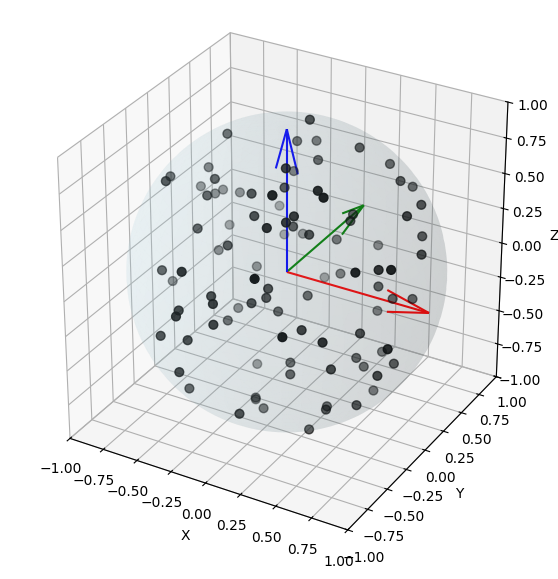

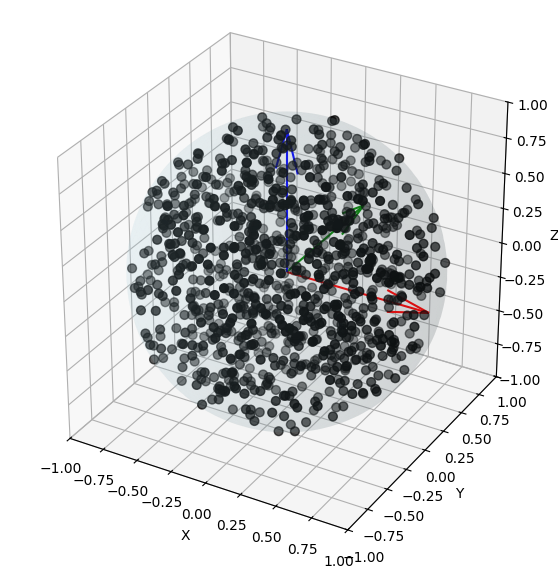

In [5]:
bloch_points_1 = [density_to_bloch(rho) for rho in rho_training]
plot_bloch_sphere(bloch_points_1)

bloch_points_2 = [density_to_bloch(rho) for rho in rho_test]
plot_bloch_sphere(bloch_points_2)

Simulating the evoultion, let's generate the random isometry

In [6]:
#the input is a qubit and the reservoir is a 5-dimensional qudit
dim_in = 2
dim_out = [2, 5]
total_dim_out = np.prod(dim_out) # 10
dim_env = 5

def generate_random_isometry(dim_in, dim_out):
    total_dim_out = np.prod(dim_out)
    #generate a random unitary of size total_dim_out x total_dim_out
    
    U = qt.rand_unitary(total_dim_out)

    #extract the first 2 columns to form the isometry
    #convert to a dense array to slice easily, then back to Qobj
    V_matrix = U.full()[:, :dim_in]

    #qrap it in a Qobj and set the dimensions correctly
    V = qt.Qobj(V_matrix, dims=[dim_out, [dim_in]])

    #check if V.dag() * V results in a 2x2 Identity matrix
    identity_check = V.dag() * V
    A = identity_check.full()
    I = np.eye(dim_in)

    if np.allclose(A,I,atol=1e-8):
        return V


V = generate_random_isometry(dim_in, dim_out)

In [7]:
def generate_povm_family(dim, num_elements):
    """
    Generates a list of n POVM elements for a system of dimension 'dim'.
    """
    if num_elements == 1:
        return [qt.qeye(dim)]
    
    #create random positive semidefinite matrices
    raw_elements = []
    for _ in range(num_elements):
        # Using rand_complex_seeded or rand_herm
        seed = qt.rand_herm(dim, density=1.0)
        pos_matrix = seed * seed.dag() 
        raw_elements.append(pos_matrix)
    
    #sum them up to find the normalization factor
    total_sum = sum(raw_elements)
    
    #normalize: M_i = S^{-1/2} G_i S^{-1/2}
    inv_sqrt_sum = total_sum.sqrtm().inv()
    povm = [inv_sqrt_sum * G * inv_sqrt_sum for G in raw_elements]
    
    return povm

In [8]:
counts = list(range(1, 17))
povm_families = {n: generate_povm_family(5, n) for n in counts}

a = sum(povm_families[5])

print(a)

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.00000000e+00  9.15933995e-16  1.06512021e-15  4.02455846e-16
  -5.22151766e-16]
 [ 8.88178420e-16  1.00000000e+00 -9.71445147e-16 -5.27355937e-16
   2.56739074e-16]
 [ 1.50920942e-15 -9.43689571e-16  1.00000000e+00 -9.29811783e-16
   2.77555756e-16]
 [ 3.34801631e-16 -5.75928194e-16 -1.13797860e-15  1.00000000e+00
  -9.08995101e-16]
 [-1.99493200e-16  2.22044605e-16  3.33066907e-16 -9.99200722e-16
   1.00000000e+00]]


In [9]:
def compute_finite_stats(rho, povm, shots):
    """
    Computes the estimated probabilities and expectation values
    based on a finite (actually also infinite) number of measurements.
    """
    # if shots = 0, we return the theoretical probabilities without sampling
    if shots == 0:

        probs = [(M @ rho).tr().real for M in povm]

        probs = np.array(probs) / np.sum(probs)

        return probs
    
    else: 
         #calculate theoretical probabilities: p_i = Tr(M_i * rho)
         #we take the real part because Tr is Hermitian but might have tiny imag noise
         probs = [(M @ rho).tr().real for M in povm]
        
         #ensure probabilities sum to 1
         probs = np.array(probs) / np.sum(probs)
        
         #sample from the multinomial distribution
         counts = np.random.multinomial(shots, probs)
        
         #observed frequencies (Finite Statistics)
         observed_probs = counts / shots
        
         return observed_probs


# --- Example Usage ---


# Create a random density matrix for C^5
rho_te = qt.rand_dm(5)

# Select the POVM with 10 elements from our previous list
povm_10 = povm_families[10]

# Simulate 500 shots
est_probs = compute_finite_stats(rho_te, povm_10, 0)
print(est_probs)


[0.10548261 0.06159636 0.092583   0.10675356 0.10221994 0.14798387
 0.10009395 0.0644535  0.11763297 0.10120024]


In [10]:
def generate_dataset_probs(rho_list, povm, shots):
    """
    Input: List of qutip density matrices
    Output: A 2D numpy array [num_states x num_povm_elements]
    """
    num_states = len(rho_list)
    num_elements = len(povm)
    prob_matrix = np.zeros((num_states, num_elements))
    
    for idx, rho in enumerate(rho_list):
        # Using the finite statistics logic from before
        rho_qobj = qt.Qobj(rho, dims=[[2], [2]])

        # Evolution and measurement
        rho_qobj_evolved = (V * rho_qobj * V.dag()).ptrace(1)
        est_probs = compute_finite_stats(rho_qobj_evolved, povm, shots=shots)
        prob_matrix[idx, :] = est_probs
        
    return prob_matrix.T


prob_matrix_training = generate_dataset_probs(rho_training, povm_families[10],shots=1000)
print(prob_matrix_training.shape)

(10, 100)


In [11]:
w_trained = {}

for n, povm in povm_families.items():
    # Initialize a sub-dictionary for this specific 'n'
    w_trained[n] = {}
    
    # Define the shot counts you want to test
    shot_list = [0, 1000, 10000, 100000, 1000000]
    
    for s in shot_list:
        # Store using the shot count as the key

        pseudo = np.linalg.pinv(generate_dataset_probs(rho_training, povm, s))
        w_trained[n][s] = np.reshape(expe_X_train,(-1,1)).T @ pseudo

print(pseudo.shape)
print(pseudo)
print(w_trained[10][1000].shape)
print(w_trained[10][1000])


(100, 16)
[[-51.4592761   74.38109134   7.89383666 ... -22.20757679 -13.00851533
    2.90850749]
 [-17.42942501 -26.31887182 -38.32756242 ...  25.72126468  28.6517561
  -24.44800891]
 [ 67.81104177   0.89797137  -6.833347   ...  34.38179379  50.89550792
   15.22518499]
 ...
 [-54.65980995 -10.84394478  26.40973476 ... -32.68116223 -47.90872462
  -45.51370573]
 [ -1.28680532  37.06868457 -48.34542291 ... -38.4655136   62.1696966
  -57.75825166]
 [-37.82904033  50.36653489 -65.49608698 ...  42.34079936   6.6465838
  -45.66439081]]
(1, 10)
[[11.58250673 -5.66777078 -3.54044928 -4.43756285 -4.05259658  7.95430274
  -1.99270997 -6.99765651 -2.27635092 13.63929684]]


In [12]:
test_prob = {}

for n, povm in povm_families.items():

    test_prob[n] = {}

    shot_list = [0, 1000, 10000, 100000, 1000000]

    for s in shot_list:
        test_prob[n][s] = generate_dataset_probs(rho_test, povm, s)

In [13]:
MSE_Ntrain_infty = {}
for n in povm_families.keys():
    MSE_Ntrain_infty[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][0]
        est_expe_X = w @ test_prob[n][s]
        MSE_Ntrain_infty[n][s] = np.mean((est_expe_X - np.reshape(expe_X_test, (-1,1)).T)**2)

In [14]:
n_values = sorted(MSE_Ntrain_infty.keys())
shot_values = sorted(MSE_Ntrain_infty[n_values[0]].keys())

<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:16: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:16: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_10511/2993245897.py:8: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_10511/2993245897.py:16: SyntaxWarning: invalid escape sequence '\i'
  plt.title('MSE($\infty$, Ntest)')


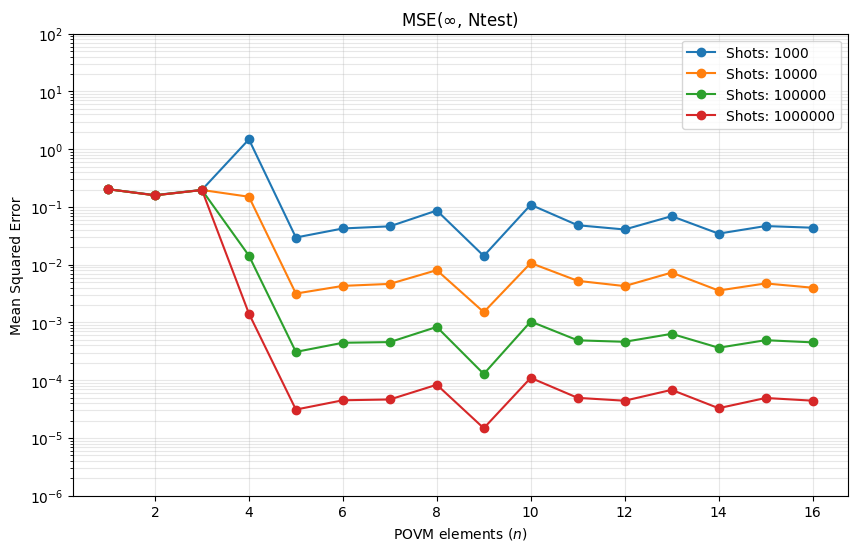

In [15]:
plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [MSE_Ntrain_infty[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE($\infty$, Ntest)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:30: SyntaxWarning: invalid escape sequence '\i'
<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:30: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_10511/980110361.py:22: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_10511/980110361.py:30: SyntaxWarning: invalid escape sequence '\i'
  plt.title('MSE (Ntrain, $\infty$)')


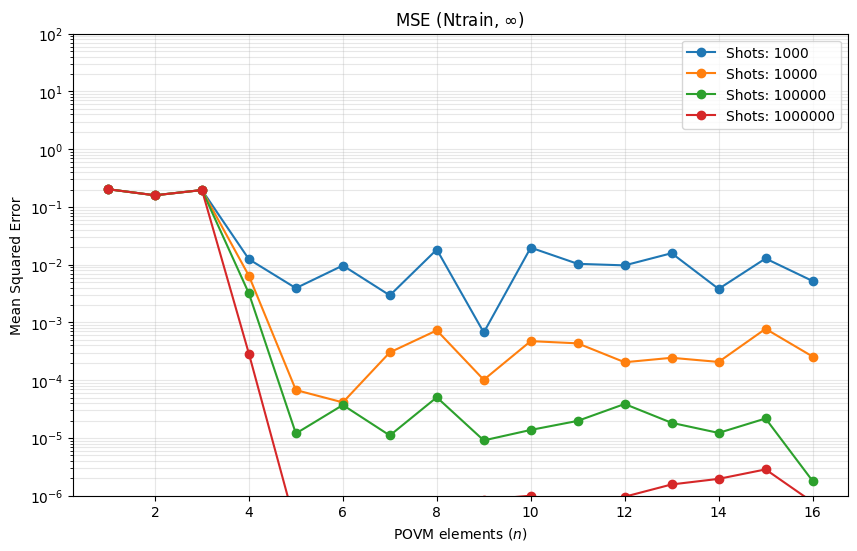

In [16]:
MSE_Ntest_infty = {}
for n in povm_families.keys():
    MSE_Ntest_infty[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][s]
        est_expe_X = w @ test_prob[n][0]
        MSE_Ntest_infty[n][s] = np.mean((est_expe_X - np.reshape(expe_X_test, (-1,1)).T)**2)

n_values = sorted(MSE_Ntest_infty.keys())
shot_values = sorted(MSE_Ntest_infty[n_values[0]].keys())

plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [MSE_Ntest_infty[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE (Ntrain, $\infty$)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\i'
<>:22: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_10511/4184857076.py:22: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"


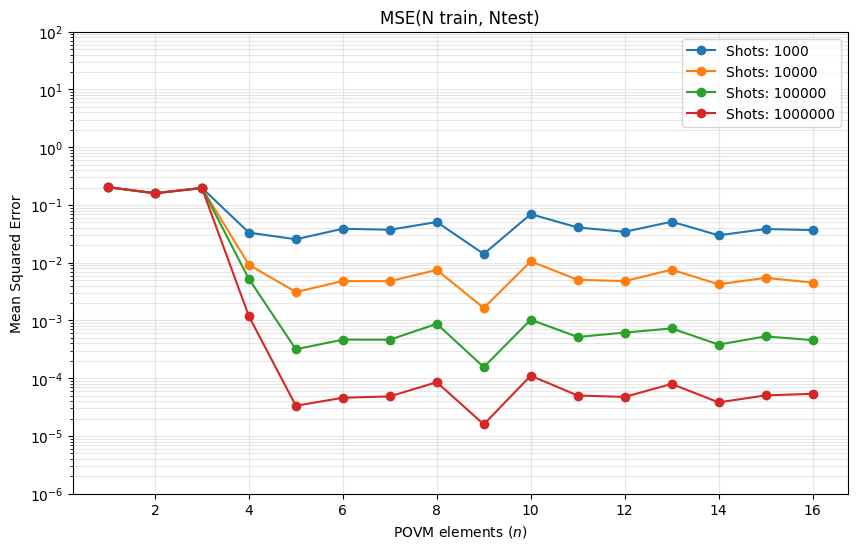

In [17]:
MSE_finite = {}
for n in povm_families.keys():
    MSE_finite[n] = {}

    shot_list = [1000, 10000, 100000, 1000000]

    for s in shot_list:
        w = w_trained[n][s]
        est_expe_X = w @ test_prob[n][s]
        MSE_finite[n][s] = np.mean((est_expe_X - np.reshape(expe_X_test, (-1,1)).T)**2)

n_values = sorted(MSE_finite.keys())
shot_values = sorted(MSE_finite[n_values[0]].keys())

plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [MSE_finite[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM elements ($n$)')
plt.ylim(1e-6, 1e2)
plt.ylabel('Mean Squared Error')
plt.title('MSE(N train, Ntest)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [18]:
train_prob = {}
k = {}

for n, povm in povm_families.items():

    train_prob[n] = {}
    k[n] = {}

    shot_list = [0, 1000, 10000, 100000, 1000000]

    for s in shot_list:
        train_prob[n][s] = generate_dataset_probs(rho_training, povm, s)

        singular_values = np.linalg.svd(train_prob[n][s], compute_uv=False)

        k[n][s] = np.max(singular_values)/np.min(singular_values)



<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:17: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:17: SyntaxWarning: invalid escape sequence '\i'
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_10511/260059056.py:9: SyntaxWarning: invalid escape sequence '\i'
  label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
/var/folders/3k/fd7stp7s1rsch3ck5w1hhcd80000gn/T/ipykernel_10511/260059056.py:17: SyntaxWarning: invalid escape sequence '\i'
  plt.title('MSE($\infty$, Ntest)')


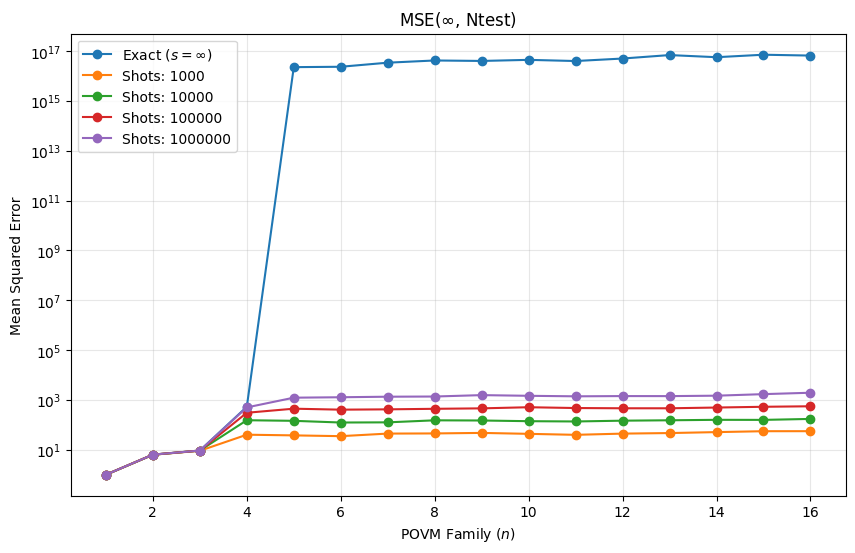

In [19]:
shot_values = sorted(k[n_values[0]].keys())
plt.figure(figsize=(10, 6))

# 2. Loop through shots to create one line per 's'
for s in shot_values:
    # Extract MSE for this specific 's' across all 'n'
    y_values = [k[n][s] for n in n_values]
    
    label = f"Shots: {s}" if s > 0 else "Exact ($s=\infty$)"
    plt.plot(n_values, y_values, marker='o', linestyle='-', label=label)

# 3. Formatting
plt.yscale('log') # Usually necessary for MSE to see the scale of improvement
plt.xlabel('POVM Family ($n$)')

plt.ylabel('Mean Squared Error')
plt.title('MSE($\infty$, Ntest)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()